# Space vs Throughput for Memory-Matched ALEX-256 Variants

Run this notebook with the repository's default uv notebook environment, for example:

```bash
uv run --extra notebook jupyter notebook result/motivation/alex_256slot_space_throughput.ipynb
```

The notebook reads checked-in benchmark summaries from this directory and plots space (GiB) versus throughput (Mops/s). Each dataset is shown in a separate subplot, including `linear` for the baseline 256-slot comparison.


In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

RESULT_DIR = Path.cwd()
if not (RESULT_DIR / "motivation_single_thread_uniform_100m_shuffled_summary.csv").exists():
    RESULT_DIR = Path("result/motivation")

MOTIVATION_SUMMARY = RESULT_DIR / "motivation_single_thread_uniform_100m_shuffled_summary.csv"
TUNING_SUMMARY = RESULT_DIR / "alex_256slot_dataset_load_factor_summary.csv"

DATASETS = ["linear", "covid", "fb-1", "osm"]
BASELINE_INDEXES = ["art", "alex", "lipp", "lipp-256slot"]
TUNED_INDEXES = {
    "linear": "alex-256slot",
    "covid": "alex-256slot-lf024",
    "fb-1": "alex-256slot-lf020",
    "osm": "alex-256slot-lf019",
}


In [2]:
motivation_full = pd.read_csv(MOTIVATION_SUMMARY)
motivation_full = motivation_full.rename(
    columns={
        "index_type": "index",
        "insert_throughput_mops_avg": "insert_mops_avg",
        "read_throughput_mops_avg": "read_mops_avg",
    }
)
motivation_full = motivation_full[motivation_full["dataset"].isin(DATASETS)]

motivation = motivation_full[motivation_full["index"].isin(BASELINE_INDEXES)]
motivation = motivation[["dataset", "index", "insert_mops_avg", "read_mops_avg", "memory_gib"]]

tuning = pd.read_csv(TUNING_SUMMARY)
tuned_rows = []
for dataset, index in TUNED_INDEXES.items():
    if dataset == "linear":
        row = motivation_full[(motivation_full["dataset"] == dataset) & (motivation_full["index"] == index)]
    else:
        row = tuning[(tuning["dataset"] == dataset) & (tuning["index"] == index)]
    if row.empty:
        raise ValueError(f"Missing tuned row for {dataset=} {index=}")
    tuned_rows.append(row.iloc[0])
tuned = pd.DataFrame(tuned_rows)[["dataset", "index", "insert_mops_avg", "read_mops_avg", "memory_gib"]]

plot_data = pd.concat([motivation, tuned], ignore_index=True)
plot_data["index"] = pd.Categorical(
    plot_data["index"],
    categories=BASELINE_INDEXES + list(TUNED_INDEXES.values()),
    ordered=True,
)
plot_data = plot_data.sort_values(["dataset", "index"]).reset_index(drop=True)
plot_data


,dataset,index,insert_mops_avg,read_mops_avg,memory_gib
0,covid,art,1.515626,1.771902,7.828843
1,covid,alex,1.753775,4.796352,3.830317
2,covid,lipp,2.292914,2.916296,16.771609
3,covid,lipp-256slot,0.453838,1.117692,28.952334
4,covid,alex-256slot-lf024,0.834334,1.221615,7.975245
5,fb-1,art,1.157122,0.978562,9.793601
6,fb-1,alex,0.719064,1.183010,4.426132
7,fb-1,lipp,1.060812,1.914789,19.521015
8,fb-1,lipp-256slot,0.463320,1.148503,23.384380
9,fb-1,alex-256slot-lf020,0.565441,0.799620,9.869490


In [3]:
throughput_data = plot_data.melt(
    id_vars=["dataset", "index", "memory_gib"],
    value_vars=["insert_mops_avg", "read_mops_avg"],
    var_name="phase",
    value_name="throughput_mops",
)
throughput_data["phase"] = throughput_data["phase"].map(
    {"insert_mops_avg": "insert", "read_mops_avg": "read"}
)
throughput_data


,dataset,index,memory_gib,phase,throughput_mops
0,covid,art,7.828843,insert,1.515626
1,covid,alex,3.830317,insert,1.753775
2,covid,lipp,16.771609,insert,2.292914
3,covid,lipp-256slot,28.952334,insert,0.453838
4,covid,alex-256slot-lf024,7.975245,insert,0.834334
5,fb-1,art,9.793601,insert,1.157122
6,fb-1,alex,4.426132,insert,0.719064
7,fb-1,lipp,19.521015,insert,1.060812
8,fb-1,lipp-256slot,23.384380,insert,0.463320
9,fb-1,alex-256slot-lf020,9.869490,insert,0.565441


## Insert throughput

Each point is one index. The x-axis is measured memory usage in GiB; the y-axis is average insert throughput over the recorded repeats.


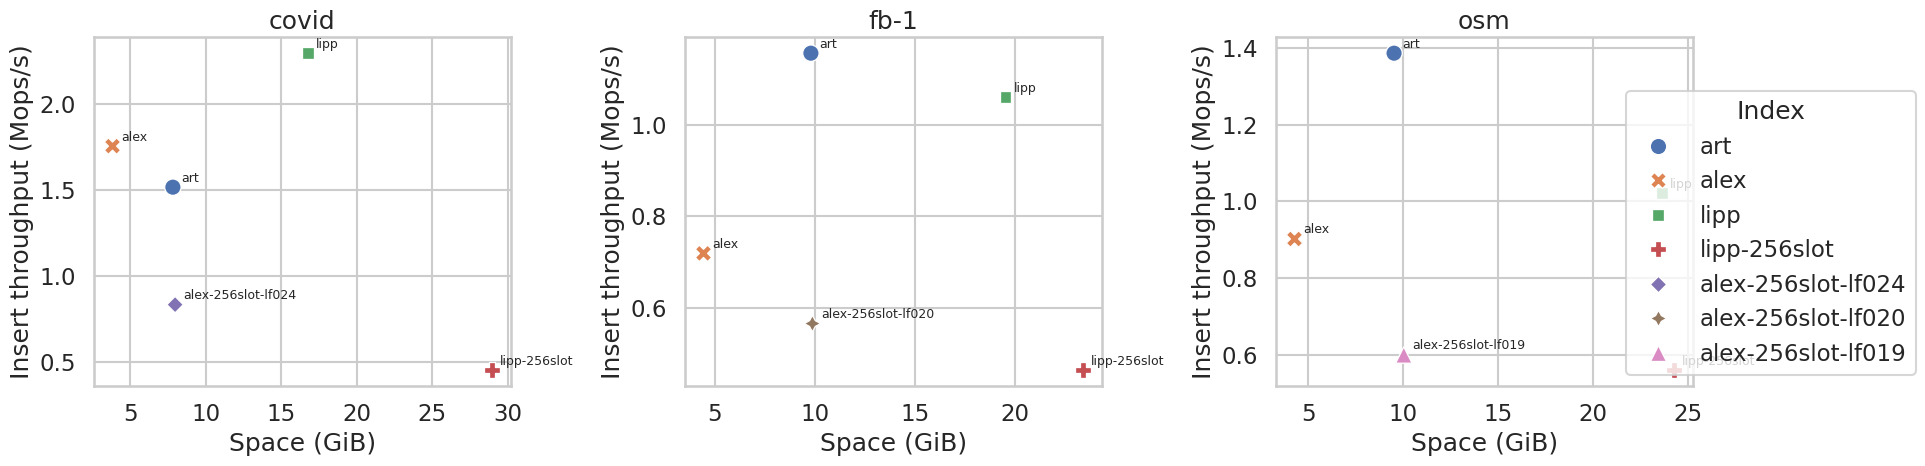

In [4]:
insert_data = throughput_data[throughput_data["phase"] == "insert"]
fig, axes = plt.subplots(1, len(DATASETS), figsize=(22, 5), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    data = insert_data[insert_data["dataset"] == dataset]
    sns.scatterplot(
        data=data,
        x="memory_gib",
        y="throughput_mops",
        hue="index",
        style="index",
        s=140,
        ax=ax,
    )
    for _, row in data.iterrows():
        ax.annotate(row["index"], (row["memory_gib"], row["throughput_mops"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
    ax.set_title(dataset)
    ax.set_xlabel("Space (GiB)")
    ax.set_ylabel("Insert throughput (Mops/s)")
    ax.get_legend().remove()
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=3, title="Index")
fig.tight_layout(rect=(0, 0, 1, 0.90))


## Read throughput

Each point is one index. The x-axis is measured memory usage in GiB; the y-axis is average read throughput over the recorded repeats.


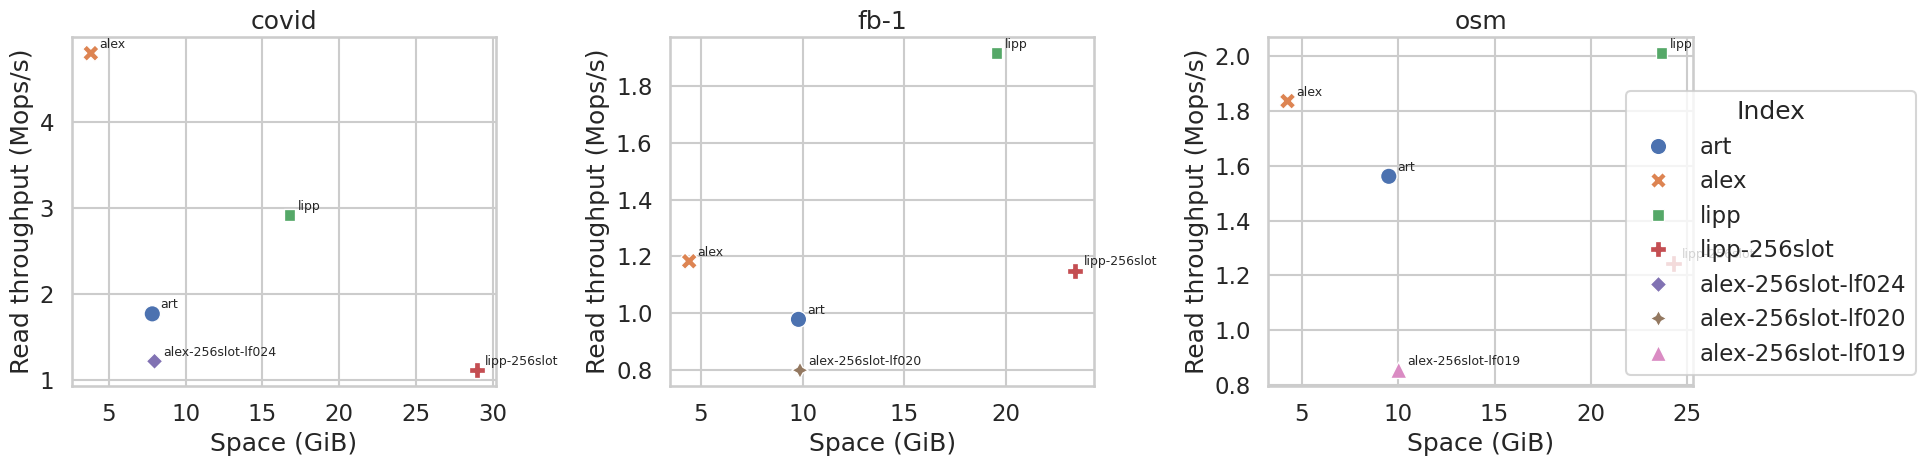

In [5]:
read_data = throughput_data[throughput_data["phase"] == "read"]
fig, axes = plt.subplots(1, len(DATASETS), figsize=(22, 5), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    data = read_data[read_data["dataset"] == dataset]
    sns.scatterplot(
        data=data,
        x="memory_gib",
        y="throughput_mops",
        hue="index",
        style="index",
        s=140,
        ax=ax,
    )
    for _, row in data.iterrows():
        ax.annotate(row["index"], (row["memory_gib"], row["throughput_mops"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
    ax.set_title(dataset)
    ax.set_xlabel("Space (GiB)")
    ax.set_ylabel("Read throughput (Mops/s)")
    ax.get_legend().remove()
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=3, title="Index")
fig.tight_layout(rect=(0, 0, 1, 0.90))
